*Печенин Данила Михайлович БПМ233. Вариант 4.*

# Распространение тепла

### Условие задачи

**Дано:**
- пластина, в которой распространяется тепло от нескольких источников
  
- коэффициенты диффузии:
    -  основного материала (синий цвет) $D_0 = 1.0$
    -  включений (белый цвет) $D_1 = 10^{-2}$

- размер массива поля температур $N \times N$, где $N \in [60, 120, 240, 480, 960]$

- размер расчетной области $60 \times 60$, т.е. для $N=60$ шаг $\Delta x = 1$, для $N=120$ шаг $\Delta x = 0.5$, ...

- $T_0 = 0$ - начальная температура во всем объеме пластины

- граничные условия на ребрах пластины двух видов:
    - фиксированная температура на ребрах
        - $x = 0$
        - $y = 0$
    - абсолютная теплоизоляция на ребрах
        - $x = 60$
        - $y = 60$

- в массе пластины расположены источники тепла, мощность которых меняется по периодическому закону:
    -  $\dot{q}_i = p_i \cdot (sin(\frac{2\pi}{\theta_i}t) + 1)$
    - источник 0: $p_0 = 100$, $\theta_0 = 37$
    - источник 1: $p_1 = 100$, $\theta_1 = 73$
    
- на пластине расположены 4 пробы (черные точки)
    
- $t_m = 600$ c - общее время моделирования

**Пример схемы пластины для варианта 0**

<img src="var_00.png" width=600/>


**Требуется:**
- согласно уравнению диффузии смоделировать распространение тепла в пластине на заданное время $t_m$ для каждого $N$
- шаг по времени $dt$ подобрать самостоятельно так, чтобы расчетная схема сходилась
- для каждого $N$:
    1. вывести время расчета
    
    2. сохранить в файл(ы) и использовать в пунктах 3-5:
        - температурное поле в конечный момент времени
        - замеры температуры в местах установки проб
        - **сохраненные файлы НЕ загружать в классрум**
    
    3. построить изображение матрицы коэффициентов диффузии

    4. построить цветовую карту поля температур в конечный момент времени
        - подписать оси,
        - отобразить цветовую шкалу `colorbar`,
        - отобразить пробы в виде точек и подписать их номера.

    5. на одном рисунке построить графики температур в местах установки всех четырех проб
        - подписать оси,
        - вывести легенду.

    6. используя быстрое преобразование Фурье, восстановить периоды колебаний температуры в местах установки проб
        - `np.fft.rfft`, `np.fft.rfftfreq`, `scipy.signal.find_peaks`
        - вероятно, понадобится вначале рассчитать полиномиальный тренд и вычесть его

    7. задокументировать все функции


**Материалы:**

- [Уравнение теплопроводности](https://ru.wikipedia.org/wiki/Уравнение_теплопроводности)
- [Solving 2D heat equation numerically using python](https://levelup.gitconnected.com/solving-2d-heat-equation-numerically-using-python-3334004aa01a)
- [Diffusion Eq 2D with Source](https://www.youtube.com/watch?v=aCRYfvh_bnY)


**Правила оценивания:**

- оценка за корректно выполненный расчет для $N$, баллов из 100:
```
    N    =   60,  120, 240, 480, 960
    g(N) =    5,    5,  10,  30,  50
```
    
- штрафы $p(i)$, баллов:
    - не выведено время расчета - 20
    - не выполнено сохранение результатов в файл(ы) - 20
    - построение графиков не использует сохраненные результаты - 20
    - не построены графики температур в местах установки проб - 20
    - не построена карта поля температур - 20
    - не построена карта коэффициентов диффузии - 10
    - не посчитаны периоды колебаний - 20
    - отсутствует документация функций - 20
    - менее значимые недоработки - 10


- итоговая оценка за задание = $\sum_{k=1}^{4}{g(N_k)} - \sum_{i}{p(i)}$


**Вариант 4**:

<img src="var_04.png" width=600/>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from typing import List, Dict, Tuple
from scipy.signal import find_peaks
from numpy.polynomial.polynomial import polyfit, polyval
import os
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Geometry
L = 60.0
T0 = 0.0
t_max = 600.0

# Diffusion coefficients
D0 = 1.0
D1 = 1e-2

# Heat sources
# [p, theta, x0, y0, width, height]. 
# All are float values.
sources = np.array([
    [100, 37, 5, 20, 5, 20],
    [100, 73, 20, 5, 20, 5]
])

# Probes
# [[x_1, y_1], [x_2, y_2], ...] - coordinates of the probes.
# All are float values.
probes = np.array([[20, 40], [40, 40], [40, 20], [20, 20]])

# White zones (with different diffusion coefficient)
# [x0, y0, width, height]. x0, y0 - coordinates of the bottom-left corner.
# All are float values.
white_zones = np.array([
    [10, 20, 5, 20],
    [20, 10, 20, 5]
])

# Grid sizes
N_list = [60, 120, 240, 480, 960]

In [ ]:
@njit
def compute_diffusion_matrix(N: int, dx: float, D0: float, D1: float, white_zones: np.ndarray) -> np.ndarray:
    """
    Constructs a spatially varying diffusion coefficient matrix for a 2D domain.

    The function builds an N × N matrix of diffusion coefficients corresponding
    to a square computational grid with spatial step `dx`. The base material
    has diffusion coefficient `D0`. Inside specified rectangular regions
    (white zones), the diffusion coefficient is set to `D1`.

    Parameters
    ----------
    N : int
        Number of grid points along each spatial direction. The resulting
        diffusion matrix has shape (N, N).

    dx : float
        Spatial grid step size.

    D0 : float
        Diffusion coefficient of the base material.

    D1 : float
        Diffusion coefficient inside the inclusion (white) zones.

    white_zones : np.ndarray
        Array of shape (K, 4), where each row describes a rectangular inclusion
        in the form [x0, y0, width, height], with coordinates given in the same
        physical units as the grid.

    Returns
    -------
    Dij : np.ndarray
        Two-dimensional array of shape (N, N) containing the diffusion
        coefficient at each grid point.
    """
    Dij = np.full((N, N), D0, dtype=np.float64)

    for z in range(white_zones.shape[0]):
        x0 = white_zones[z, 0]
        y0 = white_zones[z, 1]
        w  = white_zones[z, 2]
        h  = white_zones[z, 3]

        i0 = int(np.ceil(x0 / dx))
        i1 = int(np.ceil((x0 + w) / dx))
        j0 = int(np.ceil(y0 / dx))
        j1 = int(np.ceil((y0 + h) / dx))

        if i0 < 0: i0 = 0
        if j0 < 0: j0 = 0
        if i1 > N: i1 = N
        if j1 > N: j1 = N

        Dij[i0:i1, j0:j1] = D1

    return Dij

@njit
def get_source_indexes(sources: np.ndarray, dx: float, N: int) -> np.ndarray:
    """
    Converts physical source descriptions into grid index ranges.

    Parameters
    ----------
    sources : ndarray of shape (n_sources, 6)
        Each row: [p, theta, x0, y0, width, height]

    dx : float
        Spatial grid step.

    N : int
        Grid size.

    Returns
    -------
    sources_idx : ndarray of shape (n_sources, 6)
        Each row: [p, theta, i0, i1, j0, j1]
    """
    n = sources.shape[0]
    sources_pc = np.empty((n, 6), dtype=np.float64)

    for s in range(n):
        p, theta, x0, y0, w, h = sources[s]

        i0 = max(0, int(x0 / dx))
        i1 = min(N, int((x0 + w) / dx) + 1)
        j0 = max(0, int(y0 / dx))
        j1 = min(N , int((y0 + h) / dx) + 1)

        sources_pc[s, 0] = p
        sources_pc[s, 1] = theta
        sources_pc[s, 2] = i0
        sources_pc[s, 3] = i1
        sources_pc[s, 4] = j0
        sources_pc[s, 5] = j1

    return sources_pc

@njit
def get_probe_indexes(probes: np.ndarray, dx: float, N: int) -> np.ndarray:
    """
    Maps physical probe coordinates to nearest grid indices.

    Parameters
    ----------
    probes : ndarray of shape (n_probes, 2)
        Physical coordinates (x, y).

    Returns
    -------
    idx : ndarray of shape (n_probes, 2)
        Grid indices (i, j).
    """

    n = probes.shape[0]
    idx = np.empty((n, 2), dtype=np.int32)

    for k in range(n):
        i = int(probes[k, 0] / dx + 0.5)
        j = int(probes[k, 1] / dx + 0.5)
        idx[k, 0] = max(0, min(N-1, i))
        idx[k, 1] = max(0, min(N-1, j))

    return idx

@njit
def get_probe_temperatures(T: np.ndarray, probe_idx: np.ndarray) -> np.ndarray:
    """
    Extracts temperature values at probe grid locations.
    Parameters
    ----------
    T : ndarray of shape (N, N)
        Temperature field at a given time step.

    probe_idx : ndarray of shape (n_probes, 2)
        Grid indices of probe locations.

    Returns
    -------
    out : ndarray of shape (n_probes,)
        Temperature values at probe locations.

    """
    n = probe_idx.shape[0]
    out = np.empty(n, dtype=T.dtype)
    for k in range(n):
        i = probe_idx[k, 0]
        j = probe_idx[k, 1]
        out[k] = T[i, j]
    return out

@njit(parallel=True)
def diffuse_step(N: int, Tcur: np.ndarray, Tnxt: np.ndarray, Dij: np.ndarray, dt: float, dx: float) -> None:
    """
    Performs a single explicit diffusion step for a 2D temperature field 
    with a spatially varying diffusion coefficient.

    This function updates the temperature field using a finite-difference
    approximation of the Laplacian operator.

    Parameters
    ----------
    N : int
        Number of grid points along each spatial direction (N × N grid).

    Tcur : ndarray of shape (N, N)
        Temperature field at the current time step.

    Tnxt : ndarray of shape (N, N)
        Buffer array to store the temperature field at the next time step.

    Dij : ndarray of shape (N, N)
        Spatially varying thermal diffusion coefficient.

    dt : float
        Time step size.

    dx : float
        Spatial grid step size.

    Returns
    -------
    None
        The updated temperature field is written into `Tnxt`.
    """
    g = dt / (dx * dx)

    for i in prange(1, N - 1):
        for j in range(1, N - 1):
            lap = Tcur[i-1, j] + Tcur[i+1, j] + Tcur[i, j-1] + Tcur[i, j+1] - 4.0 * Tcur[i, j]
            D = Dij[i, j]
            Tnxt[i, j] = Tcur[i, j] + g * D * lap

@njit
def update_temperature(N: int, T: np.ndarray, buf: int, Dij: np.ndarray, dt: float, t:float,
                       dx: float, sources_pc: np.ndarray, cp_rho: float = 1.0) -> None:
    """
    Performs a single explicit time step of the 2D heat diffusion equation
    with spatially varying diffusion coefficient and internal heat sources.

    The function updates the temperature field using a finite-difference 
    approximation of the Laplacian operator.
    Boundary conditions:
        - Fixed temperature (Dirichlet): x = 0, y = 0
        - Zero heat flux (Neumann): x = L, y = L

    Parameters
    ----------
    N : int
        Number of grid points along each spatial direction (N × N grid).

    T : ndarray of shape (2, N, N)
        Temperature field at the current and previous time step. 
        T[buf] contains the current temperature field,
        T[1 - buf] is used as the next-time buffer.

    buf : int
        Index of the buffer in T where previous temperature values are stored.

    Dij : ndarray of shape (N, N)
        Spatially varying thermal diffusion coefficient.

    dt : float
        Time step size.

    t : float
        Current simulation time.

    dx : float
        Spatial grid step size.

    sources_pc : ndarray of shape (n_sources, 6)
        Heat source parameters. Each row must contain:
        [p, theta, i0, i1, j0, j1], where
            p      — amplitude of the source power,
            theta  — oscillation period,
            i0,i1  — index range along the x-direction of the source region,
            j0,j1  — index range along the y-direction of the source region.

    cp_rho : float, optional
        Product of specific heat capacity and density.
        Default is 1.0.

    Returns
    -------
    None
        The temperature field is updated in-place: the next-step values are
        written into the buffer `T[1 - buf]`.
    """
    cur = buf
    nxt = 1 - buf

    Tcur = T[cur]
    Tnxt = T[nxt]

    for s in range(sources_pc.shape[0]):
        p, theta, i0, i1, j0, j1 = sources_pc[s]
        q = p * (np.sin(2*np.pi*t/theta) + 1.0)
        heat = dt * q / cp_rho
        Tcur[i0:i1, j0:j1] += heat

    Tcur[0, :] = 0.0
    Tcur[:, 0] = 0.0
    Tcur[-1, :] = Tcur[-2, :]
    Tcur[:, -1] = Tcur[:, -2]

    diffuse_step(N, Tcur, Tnxt, Dij, dt, dx)

@njit
def simulate_heat_propagation(L: float, T0: float, t_max: float, D0: float, D1: float, sources: np.ndarray, 
                              probes: np.ndarray, white_zones: np.ndarray, N: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Simulates 2D heat diffusion in a square plate with spatially varying
    diffusion coefficient and time-dependent internal heat sources.

    The simulation is performed on a uniform N × N grid covering a physical
    domain of size Lx × Lx. An explicit finite-difference scheme is used to
    solve the heat equation with mixed boundary conditions. Temperature values
    are recorded at specified probe locations during the simulation.

    Parameters
    ----------
    Lx: float
        Physical size of the computational domain along the x-axis and y-axis.

    T0 : float
        Initial temperature in the entire domain.

    t_max : float
        Total simulation time.

    D0 : float
        Diffusion coefficient of the base material.

    D1 : float
        Diffusion coefficient of the inclusions (white zones).

    sources : ndarray of shape (n_sources, 6)
        Parameters of heat sources. Each row must contain:
        [p, theta, x0, y0, width, height], where
            p      — amplitude of the source power,
            theta  — oscillation period,
            x0,y0  — lower-left corner of the source region,
            width,
            height — spatial size of the source region.

    probes : ndarray of shape (n_probes, 2)
        Probe locations given in physical coordinates of the domain.

    white_zones : ndarray
        Array describing regions with altered diffusion coefficient D1.
        Each row defines a rectangular inclusion in physical coordinates.

    N : int
        Number of grid points along each spatial direction.

    Returns
    -------
    Dij : ndarray of shape (N, N)
        Spatial distribution of the diffusion coefficient over the grid.
        Dij[i, j] = D0 in the base material and Dij[i, j] = D1 inside white zones.

    T_final : ndarray of shape (N, N)
        Temperature field at the final simulation time t = t_max.

    probe_history : ndarray of shape (n_probes, it_max)
        Time history of temperatures recorded at probe locations.
        Each row corresponds to one probe, each column to a time step.
    """
    dx = L / (N - 1)
    C = 0.2
    dt = C * dx**2 / (4.0 * max(D0, D1))
    it_max = int(t_max / dt) + 1
    dt = t_max / it_max
    num_probes = probes.shape[0]
    probe_history = np.empty((num_probes, it_max), dtype=np.float64)
    sources_pc = get_source_indexes(sources, dx, N)
    probe_idx = get_probe_indexes(probes, dx, N)
    Dij = compute_diffusion_matrix(N, dx, D0, D1, white_zones)

    T = np.empty((2, N, N), dtype=np.float64)
    T[0, :, :] = T[1, :, :] = T0

    buf = 0

    for it in range(it_max):
        t = it * dt
        update_temperature(N, T, buf, Dij, dt, t, dx, sources_pc)
        buf = 1 - buf
        
        probe_history[:, it] = get_probe_temperatures(T[buf], probe_idx)

    return Dij, T[buf], probe_history

def run_for_all_N(L: float, T0: float, t_max: float, D0: float, D1: float, sources: np.ndarray, 
                  probes: np.ndarray, white_zones: np.ndarray, N_list: List[int]) -> Tuple[Dict[int, Tuple[np.ndarray, np.ndarray, np.ndarray, float]], float]:
    """
    Run heat diffusion simulations for multiple spatial grid resolutions.

    This function performs a series of numerical simulations of the two-dimensional
    heat diffusion equation on a square domain of fixed physical size. For each
    spatial resolution N provided in `N_list`, the domain is discretized using
    an N × N uniform grid, and the heat propagation problem is solved using an
    explicit finite-difference scheme.

    Parameters
    ----------
    L : float
        Physical length of the computational domain along both x and y directions.
        The domain is assumed to be square: [0, L] × [0, L].

    T0 : float
        Initial temperature of the domain at time t = 0.

    t_max : float
        Final simulation time.

    D0 : float
        Diffusion coefficient of the base (background) material.

    D1 : float
        Diffusion coefficient of the inclusions (white zones) embedded in the base
        material.

    sources : np.ndarray
        Array of heat source parameters. Each source is defined in physical
        coordinates and may include properties such as power, position, and
        spatial extent.

    probes : np.ndarray
        Array of probe coordinates in physical space. Each probe is defined by
        its (x, y) position and is used to record the temporal evolution of the
        temperature at that point.

    white_zones : np.ndarray
        Array describing regions with modified diffusion coefficient D1.
        Each row corresponds to a rectangular inclusion defined by
        (x0, y0, width, height), where (x0, y0) is the bottom-left corner
        in physical coordinates.

    N_list : List[int]
        List of spatial grid sizes. Each value N corresponds to a simulation
        performed on an N × N uniform grid covering the same physical domain.

    Returns
    -------
    all_results : Dict[int, Tuple[np.ndarray, np.ndarray, np.ndarray, float]]
        Dictionary mapping each grid size N to the corresponding simulation result.
        Each entry contains a tuple with:
            - Dij : ndarray of shape (N, N)
                Spatial distribution of the diffusion coefficient over the grid.
            - T_final : ndarray of shape (N, N)
                Temperature field at the final simulation time t = t_max.
            - probe_history : ndarray of shape (n_probes, it_max)
                Time history of temperatures recorded at probe locations.
            - calculation_time : float
                Wall-clock time (in seconds) spent on the simulation for this N.

    total_time : float
        Total wall-clock time (in seconds) spent executing all simulations in
        `N_list`.
    """
    all_results = {}
    total_time_start = time.time()

    for N in N_list:
        print(f"Computing for N: {N}")
        start_time = time.time()
        Dij, T_final, probe_history = simulate_heat_propagation(L, T0, t_max, D0, D1, sources, probes, white_zones, N)
        calculation_time = time.time() - start_time
        all_results[N] = (Dij, T_final, probe_history, calculation_time)
        print(f"Spent time for N={N}: {calculation_time:.2f}s")
        os.makedirs("results", exist_ok=True)
        np.savez(f"results/resultt_{N}.npz",
            Dij=Dij,
            T_final=T_final,
            probe_history=probe_history)

    total_time = time.time() - total_time_start

    print(f"Total time for all N in N_list is {total_time}s")
        
    return all_results, total_time

In [4]:
def plot_simulation_results(Dij: np.ndarray, T_final: np.ndarray, probe_history: np.ndarray, probes: np.ndarray,
    L: float, t_max: float, D0: float, C: float = 0.2, fft_threshold: float = 0.1) -> None:
    """
    Visualizes results of the 2D heat diffusion simulation.

    Produces:
    1. Visualization of the diffusion coefficient matrix
    2. Visualization of the final temperature field with probe locations
    3. Visualization of temperature evolution at probe locations
    4. FFT spectra and dominant oscillation periods at probes

    Parameters
    ----------
    Dij : ndarray (N, N)
        Diffusion coefficient matrix.

    T_final : ndarray (N, N)
        Temperature field at the final time step.

    probe_history : ndarray (n_probes, n_time_steps)
        Temperature history recorded at probe locations.

    probes : ndarray (n_probes, 2)
        Probe coordinates in physical space.

    L : float
        Physical size of the square computational domain.

    t_max : float
        Total simulation time.

    D0 : float
        Diffusion coefficient of the base material, used for calculating stable time step.

    C : float, optional
        Courant-like number for explicit scheme stability (default is 0.2).

    fft_threshold : float, optional
        Relative threshold for peak detection in FFT spectrum.
    """
    N = T_final.shape[0]
    print(f"Visualizing results for N={N}:")
    dx = L / (N - 1)
    
    dt = C * dx**2 / (4.0 * max(D0, D1))
    it_max = int(t_max / dt) + 1
    dt = t_max / it_max

    probes_idx = (probes / dx).astype(int)

    # Diffusion matrix
    plt.figure(figsize=(6, 5))
    plt.pcolormesh(Dij)
    plt.colorbar(label="Diffusion coefficient D")
    plt.xlabel("x index")
    plt.ylabel("y index")
    plt.title("Diffusion coefficient matrix")
    plt.tight_layout()
    plt.show()

    # Final temperature field
    plt.figure(figsize=(6, 5))
    plt.pcolormesh(T_final, cmap='inferno')
    plt.colorbar(label="Temperature")
    plt.xlabel("x index")
    plt.ylabel("y index")
    plt.title("Temperature field at final time")

    for k, (i, j) in enumerate(probes_idx):
        plt.scatter(i, j, c="cyan", s=40)
        plt.text(i + 5, j + 5, f"{k}", color="cyan")

    plt.tight_layout()
    plt.show()

    time = np.linspace(0.0, t_max, probe_history.shape[1])

    plt.figure(figsize=(7, 4))
    for k in range(probe_history.shape[0]):
        plt.plot(time, probe_history[k], label=f"Probe {k}")

    plt.xlabel("Time")
    plt.ylabel("Temperature")
    plt.title("Temperature evolution at probe locations")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 4. FFT analysis
    plt.figure(figsize=(7, 5))

    for k in range(probe_history.shape[0]):
        signal = probe_history[k]

        t_idx = np.arange(len(signal))
        coeffs = polyfit(t_idx, signal, 2)
        trend = polyval(t_idx, coeffs)
        detrended = signal - trend

        spectrum = np.abs(np.fft.rfft(detrended))
        freqs = np.fft.rfftfreq(len(detrended), dt)

        peaks, _ = find_peaks(
            spectrum,
            height=fft_threshold * spectrum.max()
        )

        plt.plot(freqs, spectrum, label=f"Probe {k}")
        plt.scatter(freqs[peaks], spectrum[peaks], s=30)

        periods = 1.0 / freqs[peaks]
        print(f"Probe {k}: dominant periods = {periods}")

    plt.xlabel("Frequency")
    plt.ylabel("Amplitude")
    plt.title("FFT spectra at probe locations")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [5]:
all_results, _ = run_for_all_N(L, T0, t_max, D0, D1, sources, probes, white_zones, N_list)

Computing for N: 60
Spent time for N=60: 3.02s
Computing for N: 120
Spent time for N=120: 2.94s
Computing for N: 240
Spent time for N=240: 13.95s
Computing for N: 480
Spent time for N=480: 76.27s
Computing for N: 960
Spent time for N=960: 683.18s
Total time for all N in N_list is 779.4565761089325s


Visualizing results for N=60:


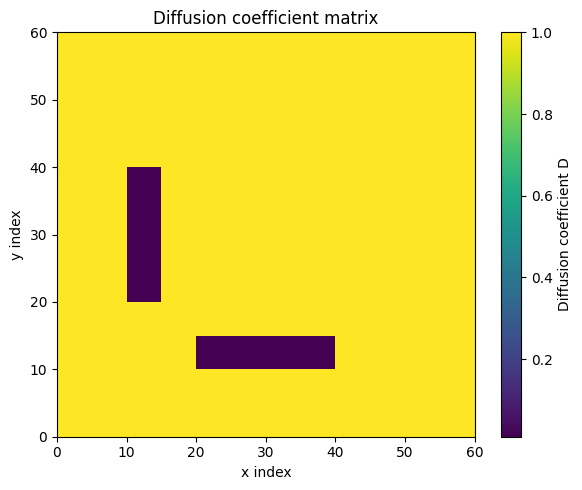

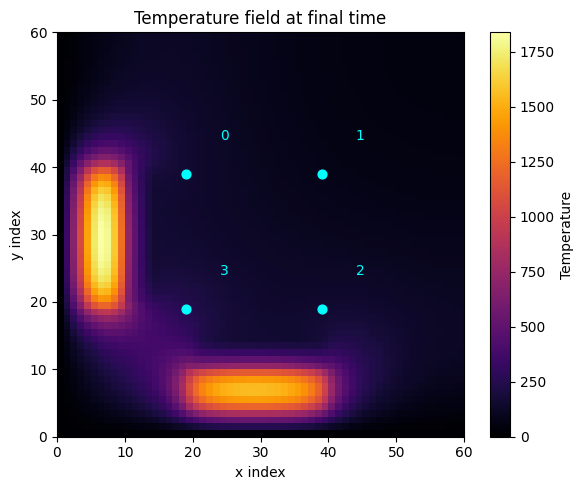

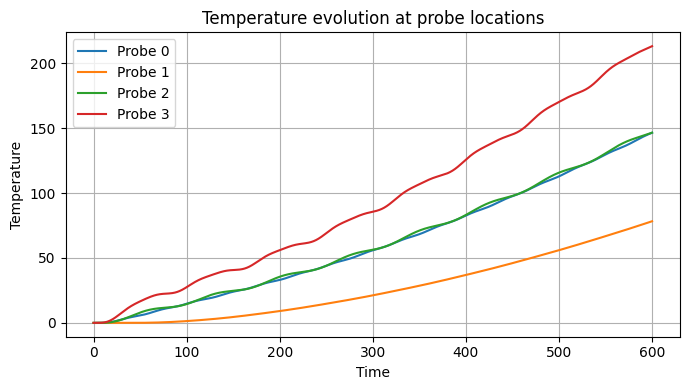

Probe 0: dominant periods = [300.   75.   37.5]
Probe 1: dominant periods = [600.]
Probe 2: dominant periods = [300.  75.]
Probe 3: dominant periods = [300.   75.   37.5]


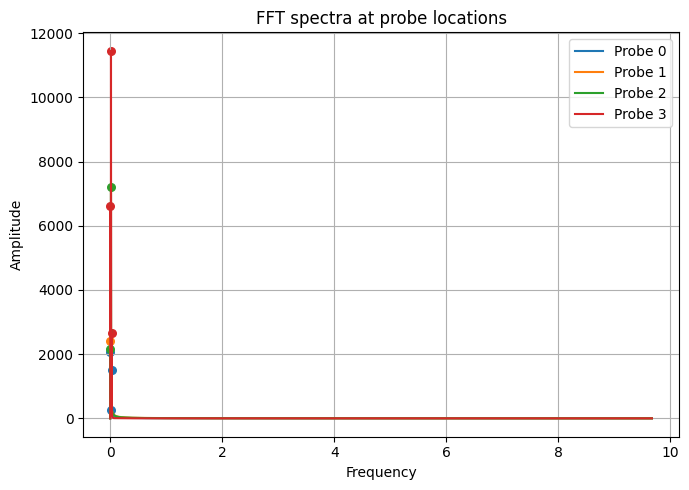

In [6]:
result_60 = np.load("results/resultt_60.npz")
plot_simulation_results(
    Dij=result_60["Dij"],
    T_final=result_60["T_final"],
    probe_history=result_60["probe_history"],
    probes=probes,
    L=L,
    t_max=t_max,
    D0=D0
)

Visualizing results for N=120:


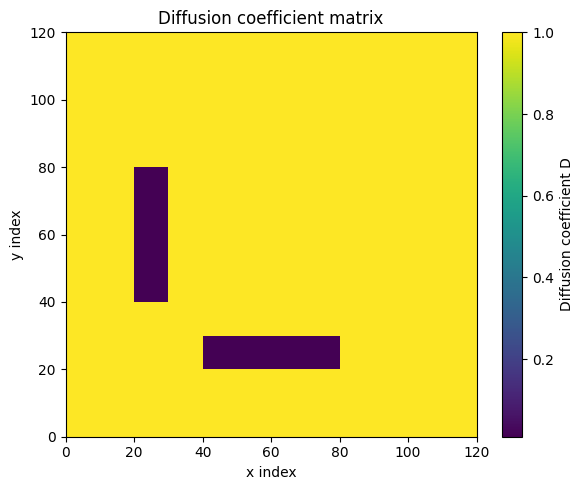

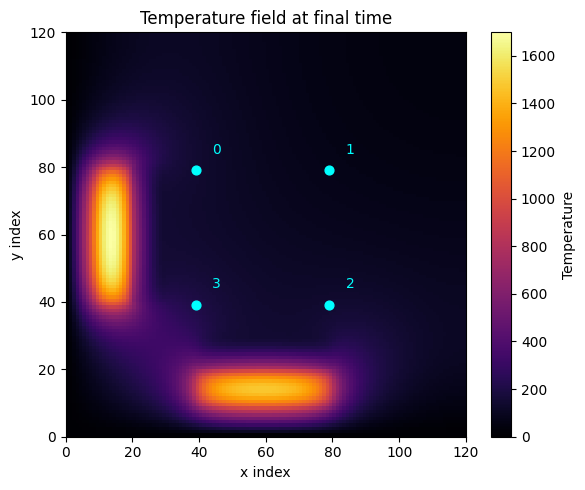

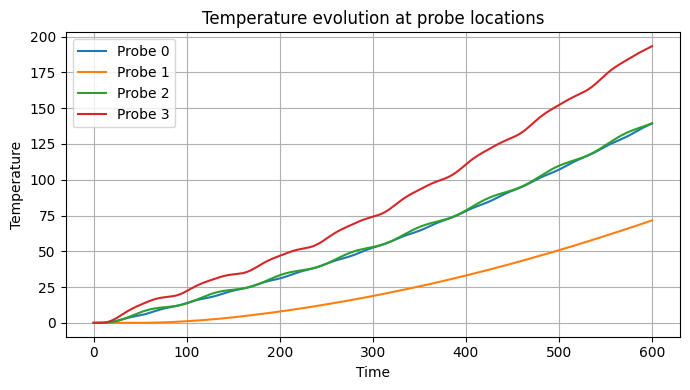

Probe 0: dominant periods = [300.   37.5]
Probe 1: dominant periods = [600.]
Probe 2: dominant periods = [300.  75.]
Probe 3: dominant periods = [300.   75.   37.5]


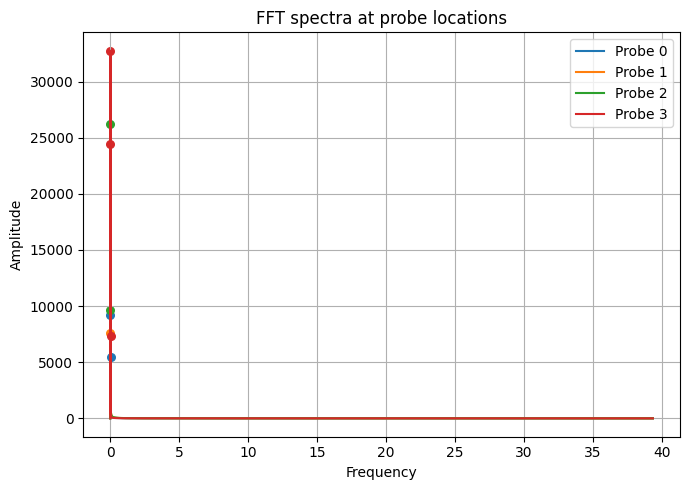

In [7]:
result_120 = np.load("results/resultt_120.npz")
plot_simulation_results(
    Dij=result_120["Dij"],
    T_final=result_120["T_final"],
    probe_history=result_120["probe_history"],
    probes=probes,
    L=L,
    t_max=t_max,
    D0=D0
)

Visualizing results for N=240:


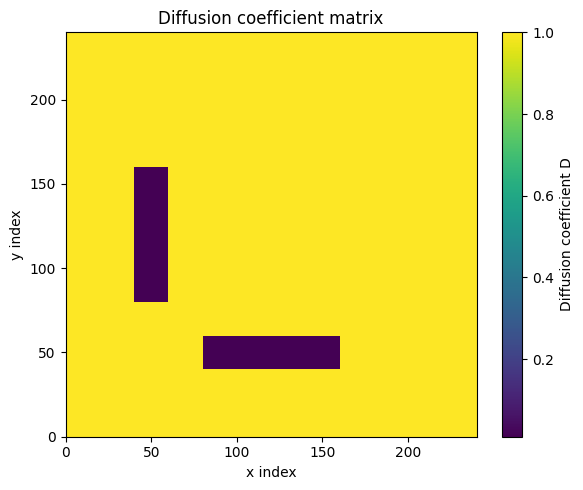

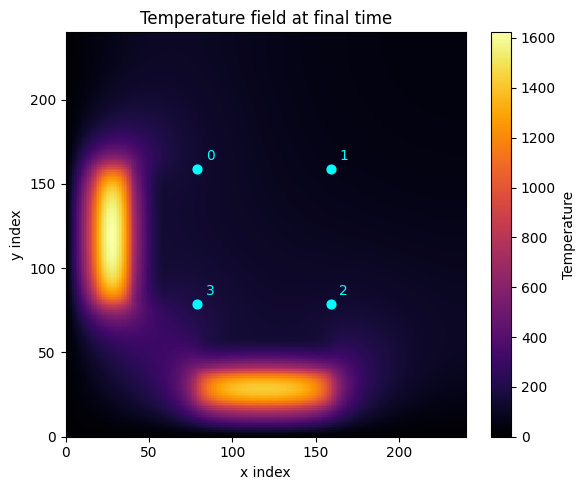

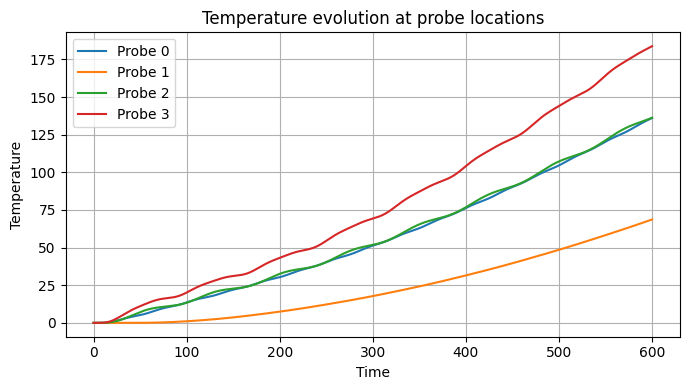

Probe 0: dominant periods = [300.   37.5]
Probe 1: dominant periods = [600. 200.]
Probe 2: dominant periods = [300.  75.]
Probe 3: dominant periods = [300.   75.   37.5]


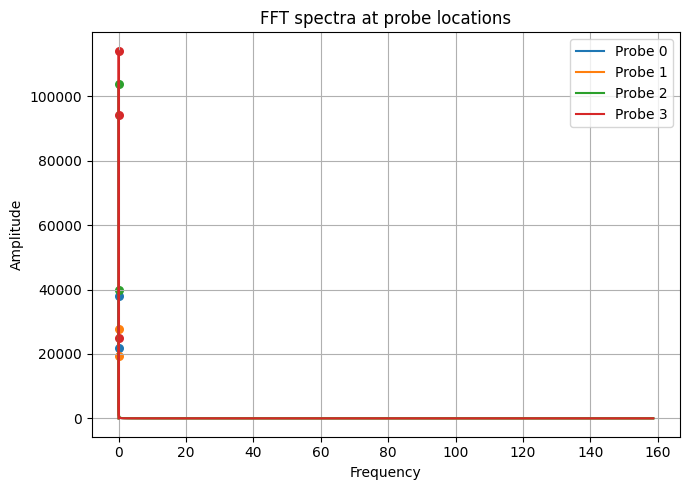

In [8]:
result_240 = np.load("results/resultt_240.npz")
plot_simulation_results(
    Dij=result_240["Dij"],
    T_final=result_240["T_final"],
    probe_history=result_240["probe_history"],
    probes=probes,
    L=L,
    t_max=t_max,
    D0=D0
)

Visualizing results for N=480:


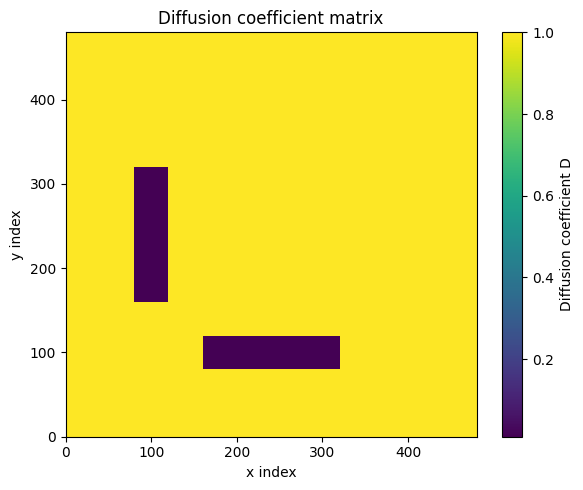

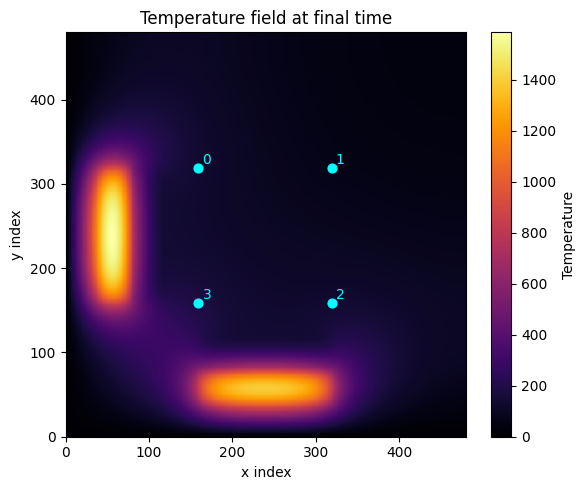

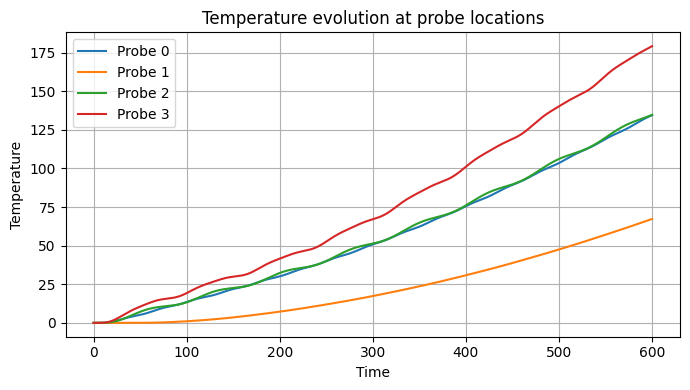

Probe 0: dominant periods = [300.   37.5]
Probe 1: dominant periods = [600. 200.]
Probe 2: dominant periods = [300.  75.]
Probe 3: dominant periods = [300.   75.   37.5]


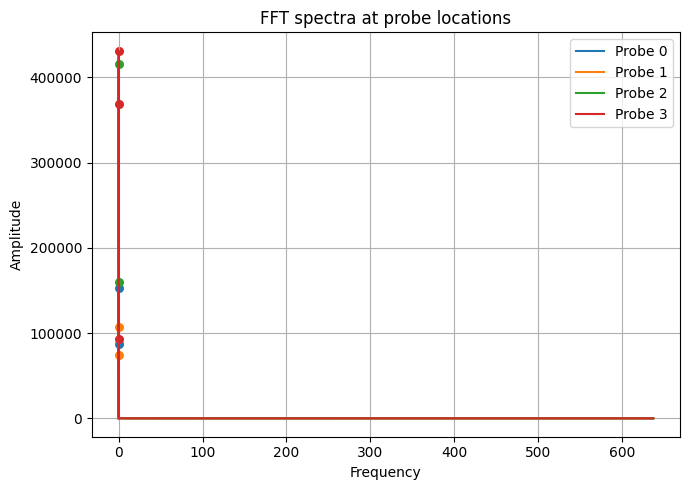

In [9]:
result_480 = np.load("results/resultt_480.npz")
plot_simulation_results(
    Dij=result_480["Dij"],
    T_final=result_480["T_final"],
    probe_history=result_480["probe_history"],
    probes=probes,
    L=L,
    t_max=t_max,
    D0=D0
)

Visualizing results for N=960:


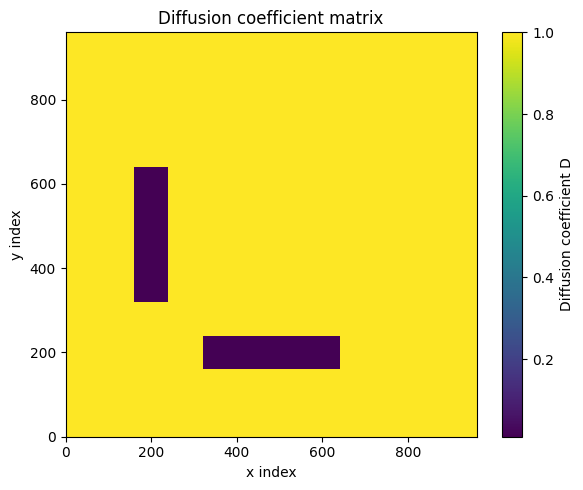

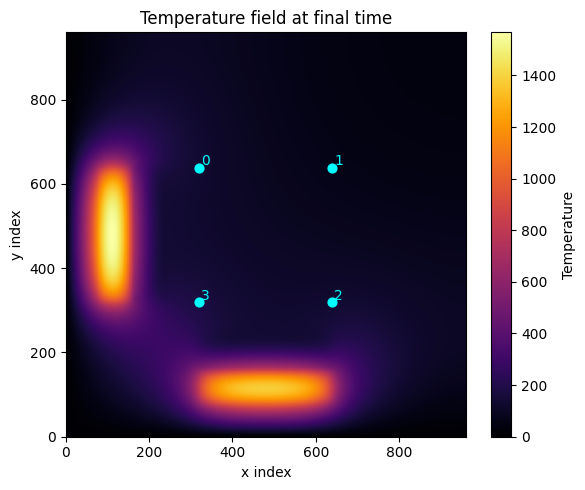

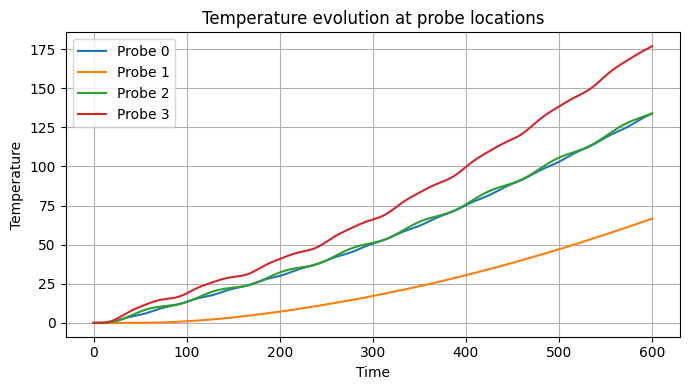

Probe 0: dominant periods = [300.   37.5]
Probe 1: dominant periods = [600. 200.]
Probe 2: dominant periods = [300.  75.]
Probe 3: dominant periods = [300.   75.   37.5]


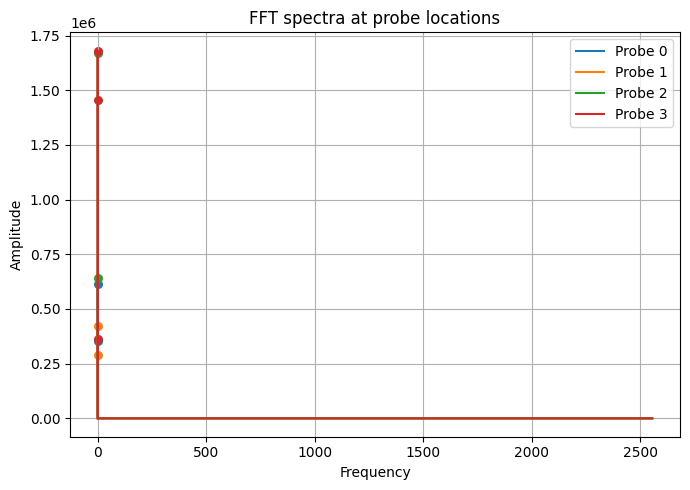

In [10]:
result_960 = np.load("results/resultt_960.npz")
plot_simulation_results(
    Dij=result_960["Dij"],
    T_final=result_960["T_final"],
    probe_history=result_960["probe_history"],
    probes=probes,
    L=L,
    t_max=t_max,
    D0=D0
)